# stock market predictor

## downloading S&P 500 price data

In [3]:
import yfinance as yf
import pandas as pd

In [4]:
sp500 = yf.Ticker("^GSPC") # get class for s&p500

In [5]:
sp500 = sp500.history(period="max")

In [6]:
sp500 # show price on single trading day + high/lows
# we will use these columns to predict if stock price will go up or down tomorrow

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,0.0,0.0
2026-03-10 00:00:00-04:00,6796.560059,6845.080078,6759.740234,6781.479980,5944950000,0.0,0.0
2026-03-11 00:00:00-04:00,6790.089844,6811.149902,6745.589844,6775.799805,5511090000,0.0,0.0


In [7]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-03-02 00:00:00-05:00', '2026-03-03 00:00:00-05:00',
               '2026-03-04 00:00:00-05:00', '2026-03-05 00:00:00-05:00',
               '2026-03-06 00:00:00-05:00', '2026-03-09 00:00:00-04:00',
               '2026-03-10 00:00:00-04:00', '2026-03-11 00:00:00-04:00',
               '2026-03-12 00:00:00-04:00', '2026-03-13 00:00:00-04:00'],
              dtype='datetime64[s, America/New_York]', name='Date', length=24666, freq=None)

## cleaning and visualizing data

<Axes: xlabel='Date'>

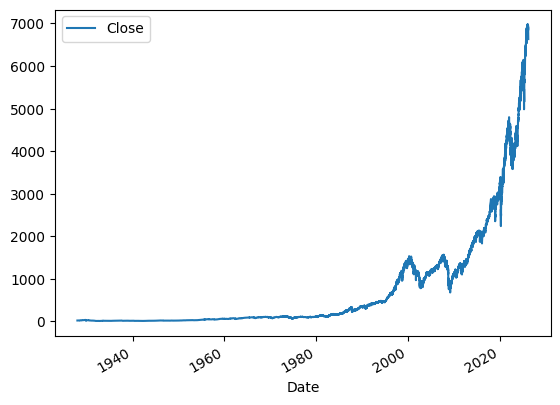

In [8]:
sp500.plot.line(y="Close", use_index=True)

In [9]:
# clean up - remove extra columns
del sp500["Dividends"]
del sp500["Stock Splits"]

In [10]:
sp500

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
...,...,...,...,...,...
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000
2026-03-10 00:00:00-04:00,6796.560059,6845.080078,6759.740234,6781.479980,5944950000
2026-03-11 00:00:00-04:00,6790.089844,6811.149902,6745.589844,6775.799805,5511090000


In [11]:
# can either predict absolute price or directionality (up or down)
# for stocks, absolute price could not be very helpful, because we want to make money based on if a stock is going up or down
# TARGET: trying to confirm whether a stock will keep going up

sp500["Tomorrow"] = sp500["Close"].shift(-1) # create a "tomorrow" column which has closing price shifted back by 1 day
sp500

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,6781.479980
2026-03-10 00:00:00-04:00,6796.560059,6845.080078,6759.740234,6781.479980,5944950000,6775.799805
2026-03-11 00:00:00-04:00,6790.089844,6811.149902,6745.589844,6775.799805,5511090000,6672.620117


In [12]:
# based on tomorrow's price, we can set up a target - whether tomorrow's price is greater than today's
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
sp500 # 0 = price went down, 1 = price went up

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0
...,...,...,...,...,...,...,...
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,6781.479980,0
2026-03-10 00:00:00-04:00,6796.560059,6845.080078,6759.740234,6781.479980,5944950000,6775.799805,0
2026-03-11 00:00:00-04:00,6790.089844,6811.149902,6745.589844,6775.799805,5511090000,6672.620117,0


In [13]:
# historical data = good most of the time, but not always for historical data
# remove all data before 1990
sp500 = sp500.loc["1990-01-01":].copy()
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,6781.479980,0
2026-03-10 00:00:00-04:00,6796.560059,6845.080078,6759.740234,6781.479980,5944950000,6775.799805,0
2026-03-11 00:00:00-04:00,6790.089844,6811.149902,6745.589844,6775.799805,5511090000,6672.620117,0


## training an initial ml model

In [14]:
from sklearn.ensemble import RandomForestClassifier
# random forest model = training individual decision trees from many parameters
# averages results from these decision trees -- resistant to overfitting
# runs quickly and can pick up non linear tendencies

In [15]:
# create model
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

n_estimators: number of individual decision trees we want to train - more = higher accurate

min_samples_split: protection against overfitting - decision trees built to deeply have tendency to overfit - higher we set it, the less accurate model will be, but less overfit there will be

random_state: random forest has randomization - setting random state will allow random numbers generated to be in predictable sequence each time - rerunning model twice will get same results

In [16]:
# split model into train and test set
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

time series data - can't use cross validation

if we did, the results would look amazing in training, horrible in real world. if we use cross validation that doesn't take tiome series nature into account, we would be using future data to predict the past --> LEAKAGE (future data leaks information into model)

predicting stock price tomorrow would be easier if we already knew price in 30 days -- can't have knowledge about future in real world

In [17]:
# list of all of columns we will use to predict target
predictors = ["Close", "Volume", "Open", "High", "Low"]

# fit model - using predictor models to try and predict target
model.fit(train[predictors], train["Target"])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


predictor columns should be EXPLICIT - do they actually affect and make predictions accurate in real life?

In [18]:
# measuer accuracy of model - IMPORTANT
from sklearn.metrics import precision_score

# what percentage of the time when we said market would go up, did it actually go up?
# assume that we want to buy stock - hold, then sell -- need to make sure stock price actually increases
preds = model.predict(test[predictors])
preds # numpy array

array([0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0])

In [19]:
preds = pd.Series(preds, index=test.index)
preds

Date
2025-10-20 00:00:00-04:00    0
2025-10-21 00:00:00-04:00    0
2025-10-22 00:00:00-04:00    1
2025-10-23 00:00:00-04:00    1
2025-10-24 00:00:00-04:00    0
                            ..
2026-03-09 00:00:00-04:00    1
2026-03-10 00:00:00-04:00    0
2026-03-11 00:00:00-04:00    0
2026-03-12 00:00:00-04:00    1
2026-03-13 00:00:00-04:00    0
Length: 100, dtype: int64

In [20]:
# turn into pandas series
combined = pd.concat([test["Target"], preds], axis=1)
combined

,Target,0
Date,,
2025-10-20 00:00:00-04:00,1,0
2025-10-21 00:00:00-04:00,0,0
2025-10-22 00:00:00-04:00,1,1
2025-10-23 00:00:00-04:00,1,1
2025-10-24 00:00:00-04:00,1,0
...,...,...
2026-03-09 00:00:00-04:00,0,1
2026-03-10 00:00:00-04:00,0,0
2026-03-11 00:00:00-04:00,0,0


In [21]:
# calculate precision score
precision_score(test["Target"], preds)

0.6666666666666666

the stock price went up 66% of time when we thought it would go up

In [22]:
# we can keep improving the model
combined = pd.concat([test["Target"], preds], axis=1) # combine test and predicted values

<Axes: xlabel='Date'>

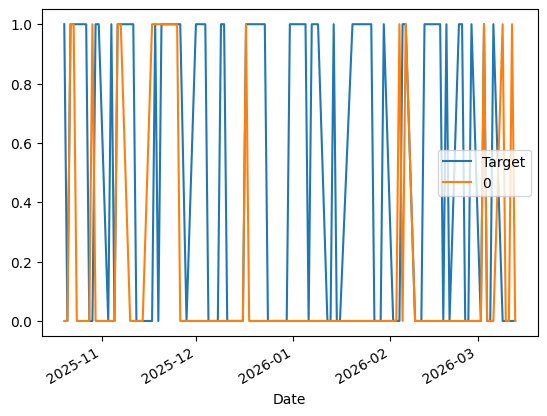

In [23]:
combined.plot()

## building a backtesting system

we want to build a more robust way to test the algorithm
- test across multiple years of data
- we want to know how algorithm would handle many different situations

In [28]:
def predict(train, test, predictors, model): # wrap everything we just did into function
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

when we backtest, we need to have certain amount of data to train first model
- 250 = number of trading days in year

start: take 10 years of data, and train first model w 10 years of data

step: train model for around a year, then go to each year after

goal is to take the first 10 years of data, then predict values for 11th year, then take 11 years of data to predict for 12th year, etc - increasing confidence for model

In [29]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    
    return pd.concat(all_predictions) # take list of dataframes and combine into one

In [30]:
predictions = backtest(sp500, model, predictors) # backtest with model and predictions from earlier

In [31]:
# evaluate error of predictions
predictions["Predictions"].value_counts()

Predictions
0    3946
1    2670
Name: count, dtype: int64

market will go up on 2670 days

In [32]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5307116104868914

we were about 53% precise - went up 53% of time when we said it would go up

In [33]:
# is that good? we can look at the percentage of days where the market actually went up
predictions["Target"].value_counts() / predictions.shape[0]

Target
1    0.537031
0    0.462969
Name: count, dtype: float64

s&p actually went up 53.7% of days and down 46.2% of days - so if we had decided to buy at beginning of day and sell at end of day everyday, we would do better than our algorithm (53.0%) - natural > algorithm
- however, backtesting gives us confidence in our model and ability to test it

## adding additional predictors to our model

we will create a variety of rolling averages. human analysts look at stock prices compared to the past and use all of those inputs to help determine if the stock will go up or down. we will give the algorithm that information
- horizons will give algorithm rolling means (past week, month, 3 months, 6 months, etc)

In [35]:
# last 2 days, trading week, 3 months, year, 4 years
horizons = [2, 5, 60, 250, 1000]

# try to find ratio between today's closing price and closing price in those periods - identify possible trends and give more info
new_predictors = [] # hold new columns we will create

In [38]:
for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()

    # for each time through loop it will be ratio between today in last 2 days, last 5 days, etc
    ratio_column = f"Close_Ration{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]

    # number of days in past X days that stock price actually went up
    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"] # will look at past few days and seee sum of target 

    new_predictors += [ratio_column, trend_column]

In [39]:
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ration2,Close_Ration5,Close_Ration60,Close_Ration250,Close_Ration1000,Trend_2,Trend_5,Trend_60,Trend_250,Trend_1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,0.993731,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,6781.479980,0,1.004135,0.997859,0.986452,1.064671,1.327852,1.0,2.0,31.0,144.0,538.0
2026-03-10 00:00:00-04:00,6796.560059,6845.080078,6759.740234,6781.479980,5944950000,6775.799805,0,0.998931,0.996758,0.984597,1.061593,1.324342,1.0,2.0,30.0,144.0,538.0
2026-03-11 00:00:00-04:00,6790.089844,6811.149902,6745.589844,6775.799805,5511090000,6672.620117,0,0.999581,0.998673,0.984070,1.059923,1.322584,0.0,1.0,29.0,143.0,537.0


when pandas cannot find enough days to find rolling average, it will return NaN
- trend cant include current day - so it looks for two previous days

In [40]:
# get rid of some extra rows with NaN
sp500 = sp500.dropna()
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ration2,Close_Ration5,Close_Ration60,Close_Ration250,Close_Ration1000,Trend_2,Trend_5,Trend_60,Trend_250,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,0.996617,1.000283,1.028047,1.176082,1.0,1.0,32.0,127.0,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.995899,0.997329,1.025151,1.172676,0.0,1.0,32.0,126.0,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,0.999495,1.000311,1.028274,1.176163,1.0,2.0,32.0,127.0,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,1.004991,1.006561,1.034781,1.183537,2.0,3.0,32.0,128.0,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.003784,1.005120,1.033359,1.181856,1.0,2.0,32.0,128.0,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-06 00:00:00-05:00,6769.029785,6773.419922,6711.560059,6740.020020,5793120000,6795.990234,1,0.993317,0.987159,0.978223,1.056685,1.317584,0.0,2.0,30.0,143.0,537.0
2026-03-09 00:00:00-04:00,6699.799805,6810.439941,6636.040039,6795.990234,6709410000,6781.479980,0,1.004135,0.997859,0.986452,1.064671,1.327852,1.0,2.0,31.0,144.0,538.0
2026-03-10 00:00:00-04:00,6796.560059,6845.080078,6759.740234,6781.479980,5944950000,6775.799805,0,0.998931,0.996758,0.984597,1.061593,1.324342,1.0,2.0,30.0,144.0,538.0


data now starts in 1993 - due to closed_ratio1000 columns (needed 4 years of data)

## improving our model

can update model slightly and change some parameters

In [41]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1) # change our parameters slightly

In [43]:
# we want a bit more control over how we define what becomes 1 and what becomes 0
def predict(train, test, predictors, model): 
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1] # will return probability that the row will be 0 or 1 (of stock price going down or up)
    preds[preds >= .6] = 1 # model has to be more confident that price will go up to show that price will go up - will reduce number of trading days, but increase the chance that price will actually go up on those days
    preds[preds < .6] = 0 # dont want to be trading every single day
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [44]:
predictions = backtest(sp500, model, new_predictors)

we get rid of using close, low, high, volume columns - they are absolute numbers, and not super informative to model 
- we want the actual ratio and whether the prices are going to go up in comparison to past/future 

In [45]:
predictions["Predictions"].value_counts()

Predictions
0.0    4739
1.0     876
Name: count, dtype: int64

predicts that price will go up on much less days because we changed the threshold - we asked the model to be more confident in predictions before price will go up
- hopefully this means we will be more accurate on those days

In [46]:
# check precision score
precision_score(predictions["Target"], predictions["Predictions"])

0.571917808219178

when we buy a stock, 57% of the time, it will actually go up
- pretty good considering we are just looking at time series data and historical prices of the index

## next steps and improvement

SUMMARY
1. downloaded stock data
2. cleaned and visualized it
3. set up machine learning target
4. trained model
5. evaluated error and created way to backtest
6. meassured error over long period of tim
7. improved model with extra predictor model

POSSIBLE WAYS TO IMPROVE
- worth looking into other prices from the other side of the world - if that helps predictions
- news articles / current world trends
- key components of s&p 500 
    - tech in downturn --> maybe sp500 will go down
- increase resolution - try looking at hour/minute data

In [ ]:
## next steps with model